<a href="https://colab.research.google.com/github/iagocomin/DataScience_Project/blob/main/Predicting_Student_Health_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fazendo a leitura dos dados

In [26]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
np.random.seed(10)

drive.mount('/content/drive/')
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predicting Student Health Risk/train.csv', header=(0))
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predicting Student Health Risk/test.csv', header=(0))



print("Número de linhas e colunas no conjunto de treinamento:", train.shape)
print("Número de linhas e colunas no conjunto de teste:", test.shape)
attributes = list(train.columns)
train.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas no conjunto de treinamento: (690088, 15)
Número de linhas e colunas no conjunto de teste: (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


Retiramos a coluna id do conjunto de treinamento e de teste, pois não será importante para a análise dos dados.

In [27]:
train.drop(['id'],axis = 1, inplace = True)
train.head(10)

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


In [28]:
Id_test = test['id']
test.drop(['id'],axis = 1, inplace = True)
test.head(10)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
5,8.51,72.0,21.96,2449.0,7232.0,49.9,2.56,balanced,NaN,poor,active,occasional,male
6,6.21,65.6,25.02,1788.0,4884.0,48.5,2.01,veg,high,average,moderate,yes,male
7,7.17,65.7,NaN,NaN,14082.0,NaN,1.14,veg,high,average,NaN,NaN,male
8,7.95,61.1,22.16,NaN,3228.0,0.0,2.60,balanced,high,good,sedentary,no,male
9,NaN,73.7,21.89,2121.0,8961.0,43.7,3.55,veg,NaN,average,moderate,no,NaN


Verificando quantos valores são nulos, nos conjunto de teste e de treinamento.

In [29]:
train.isnull().sum().sort_values(ascending=False).head(15)

,0
stress_level,82811
sleep_duration,75999
sleep_quality,58331
calorie_expenditure,52853
water_intake,43477
physical_activity_level,36621
smoking_alcohol,28582
gender,21373
step_count,13916
bmi,13898


In [30]:
test.isnull().sum().sort_values(ascending=False).head(15)

,0
stress_level,35490
sleep_duration,32571
sleep_quality,24999
calorie_expenditure,22652
water_intake,18633
physical_activity_level,15695
smoking_alcohol,12249
gender,9160
step_count,5964
bmi,5956


Preenchendo os atributos nulos com a média para os numéricos e a moda para os nominais.

In [31]:
train['sleep_quality'] = train['sleep_quality'].fillna(train['sleep_quality'].mode()[0])
train['heart_rate'] = train['heart_rate'].fillna(train['heart_rate'].mean())
train['exercise_duration'] = train['exercise_duration'].fillna(train['exercise_duration'].mean())
train['diet_type'] = train['diet_type'].fillna(train['diet_type'].mode()[0])
train['sleep_duration'] = train['sleep_duration'].fillna(train['sleep_duration'].mode()[0])
train['stress_level'] = train['stress_level'].fillna(train['stress_level'].mode()[0])
train['calorie_expenditure'] = train['calorie_expenditure'].fillna(train['calorie_expenditure'].mean())
train['water_intake'] = train['water_intake'].fillna(train['water_intake'].mean())
train['physical_activity_level'] = train['physical_activity_level'].fillna(train['physical_activity_level'].mode()[0])
train['smoking_alcohol'] = train['smoking_alcohol'].fillna(train['smoking_alcohol'].mode()[0])
train['gender'] = train['gender'].fillna(train['gender'].mode()[0])
train['step_count'] = train['step_count'].fillna(train['step_count'].mean())
train['bmi'] = train['bmi'].fillna(train['bmi'].mean())

test['sleep_quality'] = test['sleep_quality'].fillna(test['sleep_quality'].mode()[0])
test['heart_rate'] = test['heart_rate'].fillna(test['heart_rate'].mean())
test['exercise_duration'] = test['exercise_duration'].fillna(test['exercise_duration'].mean())
test['diet_type'] = test['diet_type'].fillna(test['diet_type'].mode()[0])
test['sleep_duration'] = test['sleep_duration'].fillna(test['sleep_duration'].mean())
test['stress_level'] = test['stress_level'].fillna(test['stress_level'].mode()[0])
test['calorie_expenditure'] = test['calorie_expenditure'].fillna(test['calorie_expenditure'].mean())
test['water_intake'] = test['water_intake'].fillna(test['water_intake'].mean())
test['physical_activity_level'] = test['physical_activity_level'].fillna(test['physical_activity_level'].mode()[0])
test['smoking_alcohol'] = test['smoking_alcohol'].fillna(test['smoking_alcohol'].mode()[0])
test['gender'] = test['gender'].fillna(test['gender'].mode()[0])
test['step_count'] = test['step_count'].fillna(test['step_count'].mean())
test['bmi'] = test['bmi'].fillna(test['bmi'].mean())


Verificando se o passo anterior foi executado com sucesso.

In [32]:
train.isnull().sum().sort_values(ascending=False).head(15)

,0
health_condition,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0
stress_level,0


In [34]:
test.isnull().sum().sort_values(ascending=False).head(15)

,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0
stress_level,0
sleep_quality,0


Transformando os atributos nominais em numéricos no conjnto de treinamento, preservando a coluna alvo como nominal (health_condition).

In [35]:
train_original = train.copy()

# Guarda a coluna alvo
target = train['health_condition']

# Remove a coluna alvo
train = train.drop(columns=['health_condition'])

# Aplica get_dummies
train = pd.get_dummies(train, drop_first=True, dtype=int)

# Insere a coluna alvo na primeira posição
train.insert(0, 'health_condition', target)

train.head(10)



,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_non-veg,diet_type_veg,stress_level_low,stress_level_medium,sleep_quality_good,sleep_quality_poor,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_occasional,smoking_alcohol_yes,gender_male,gender_other
0,unhealthy,5.22,70.6,25.66,2174.000000,1326.0,19.8,1.86,0,1,0,0,0,0,0,1,0,1,0,0
1,at-risk,5.53,71.3,25.84,1966.000000,9891.0,49.9,1.26,1,0,1,0,0,0,1,0,0,1,0,1
2,unhealthy,5.29,75.4,24.54,2688.000000,14216.0,38.1,1.60,0,1,0,0,0,1,0,0,0,1,1,0
3,unhealthy,4.70,77.2,23.13,2630.000000,7174.0,59.9,2.02,0,1,0,0,0,0,0,0,1,0,0,0
4,at-risk,7.23,73.4,28.44,2560.000000,6584.0,46.0,2.25,0,1,0,1,0,0,0,1,0,1,1,0
5,at-risk,5.11,82.8,24.43,2290.000000,2134.0,29.2,2.02,0,1,1,0,0,1,0,1,1,0,1,0
6,at-risk,8.21,71.1,24.14,2723.000000,12984.0,54.5,2.01,0,0,1,0,0,0,1,0,0,0,0,0
7,at-risk,7.47,87.0,23.51,2226.084931,3096.0,37.5,0.51,0,0,1,0,0,0,0,1,1,0,1,0
8,unhealthy,5.94,75.4,24.36,2226.084931,12165.0,61.6,1.56,0,1,0,0,0,0,0,0,0,0,0,1
9,at-risk,6.97,80.1,20.47,2928.000000,13108.0,51.9,2.53,0,1,0,1,1,0,0,0,0,0,1,0


Transformando os atributos nominais em numéricos no conjunto de teste.

In [36]:
test = pd.get_dummies(test, drop_first=True, dtype=int)
test.head(10)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_non-veg,diet_type_veg,stress_level_low,stress_level_medium,sleep_quality_good,sleep_quality_poor,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_occasional,smoking_alcohol_yes,gender_male,gender_other
0,5.350000,64.9,23.480000,2745.000000,14167.0,59.500000,1.86,0,1,0,0,0,1,0,0,1,0,1,0
1,6.993517,83.1,22.420000,1773.000000,6801.0,24.500000,2.40,0,0,0,0,0,1,0,1,0,1,0,1
2,6.680000,59.7,24.140000,3040.000000,13250.0,48.500000,2.76,0,0,0,1,0,1,0,0,0,0,1,0
3,7.130000,78.5,26.260000,2494.000000,6331.0,56.900000,2.34,0,1,1,0,1,0,1,0,0,1,0,1
4,5.490000,77.7,23.290000,1828.000000,13894.0,39.400000,2.45,0,1,0,0,0,0,0,0,1,0,0,1
5,8.510000,72.0,21.960000,2449.000000,7232.0,49.900000,2.56,0,0,0,1,0,1,0,0,1,0,1,0
6,6.210000,65.6,25.020000,1788.000000,4884.0,48.500000,2.01,0,1,0,0,0,0,1,0,0,1,1,0
7,7.170000,65.7,22.984661,2225.514941,14082.0,38.796712,1.14,0,1,0,0,0,0,0,1,0,1,1,0
8,7.950000,61.1,22.160000,2225.514941,3228.0,0.000000,2.60,0,0,0,0,1,0,0,1,0,0,1,0
9,6.993517,73.7,21.890000,2121.000000,8961.0,43.700000,3.55,0,1,0,1,0,0,1,0,0,0,1,0


Passando os dados para NumPy e fazendo a seguinte codificação da coluna alvo.

0: at_risk

1: fit

2: unhealthy

In [50]:
from sklearn.preprocessing import LabelEncoder

data_train = train.to_numpy()

nrow, ncol = data_train.shape

# Variável alvo
y_train = data_train[:,0]


# Converte as classes de texto para números
le = LabelEncoder()
y_train = le.fit_transform(y_train)

# Variáveis explicativas
X_train = data_train[:,1:ncol]


In [41]:
data_test = test.to_numpy()
X_test = data_test

Análise exploratória dos dados.

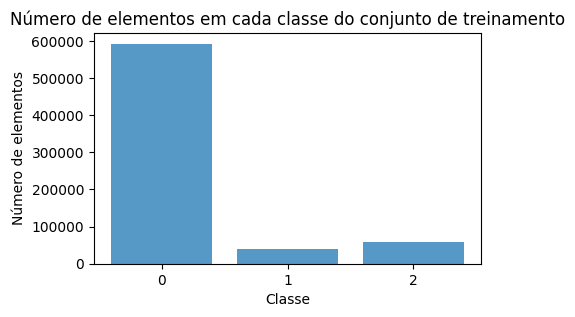

In [52]:
classes = y_train
cl = np.unique(classes)
ncl = np.zeros(len(cl))

for i in np.arange(0, len(cl)):
    a = classes == cl[i]
    ncl[i] = len(classes[a])

numbers = np.arange(0, len(cl))
plt.figure(figsize=(5, 3))
plt.bar(numbers, ncl,  alpha=.75)
plt.xticks(numbers, cl)
plt.title('Número de elementos em cada classe do conjunto de treinamento')
plt.xlabel('Classe')
plt.ylabel('Número de elementos')
plt.show(True)


In [ ]:
print(le.classes_)

['at-risk' 'fit' 'unhealthy']


Normalizando os dados

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

print('Dados transformados:')
print('Media: ', np.mean(X_train, axis = 0))
print('Desvio Padrao:', np.std(X_train, axis = 0))

print('Dados transformados:')
print('Media: ', np.mean(X_test, axis = 0))
print('Desvio Padrao:', np.std(X_test, axis = 0))

Dados transformados:
Media:  [ 2.93811081e-15 -5.09878106e-16  4.01085234e-15 -1.45310112e-15
 -2.05325813e-16  1.83931937e-15  2.73431401e-16  1.63301025e-17
  8.22682971e-18 -1.04516260e-16 -5.51630039e-18  9.66832678e-18
  9.55506629e-18  1.07535681e-16  3.11466331e-17 -3.38134027e-17
 -9.28941898e-17  7.10452127e-19  5.31294634e-18]
Desvio Padrao: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Dados transformados:
Media:  [-1.52618684e-02 -2.08458694e-03 -1.07417827e-04 -1.70676922e-03
  2.74515115e-03  3.08535130e-03  5.90914758e-03 -9.29879248e-04
 -8.18191189e-04 -6.38556200e-05  2.42722427e-03  1.32975676e-04
  1.85932286e-01 -1.04427325e-01  1.26799954e-01  1.61865458e-03
 -4.24106356e-03  3.76583235e-03  6.82419847e-02]
Desvio Padrao: [0.99974728 0.99266117 0.99875921 1.00081688 0.99878941 0.99789489
 1.00054166 0.999654   0.99973354 0.99996174 0.99999997 1.00005872
 1.05858589 0.96665423 1.04054105 1.00063959 0.99880696 1.00096062
 1.02710875]


Fazendo o treinamento do modelo Naive Bayes e vendo qual a acurácia.

In [56]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Treina o modelo
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Faz previsões
y_pred = gnb.predict(X_test)

# Volta para os nomes das classes
y_pred = le.inverse_transform(y_pred)

# Acurácia no conjunto de treino
y_pred_train = gnb.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {accuracy_train:.4f}")

# Arquivo de submissão
submission = pd.DataFrame({
    'id': Id_test,
    'health_condition': y_pred
})

submission.to_csv('submission.csv', index=False)
submission.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Predicting Student Health Risk/PSHR-naive-bayes.csv',
    index=False
)

Acurácia no conjunto de treino: 0.8777


Ao submeter no Kaggle obtemos uma taxa de acerto de 0,80936.